# DBSCAN Documentation
<h1 style="color:Green; ">#1-Introduction</h1>



<h3> DBSCAN </h3> (Density-Based Spatial Clustering of Applications with Noise) is an unsupervised clustering algorithm based on density. It is particularly useful for detecting clusters with complex shapes. Unlike K-means, it does not require knowing the number of clusters in advance, and it is capable of detecting outliers.


<h1 style="color:Green; ">#2-PRINCIPLE OF OPERATION
</h1>

DBSCAN is based on two main parameters: epsilon (ε) and minPts.  
It groups together points that are close to each other and identifies isolated points as noise.

### a) ε (Epsilon)

This is the search radius around a point. It defines the maximum distance at which two points are considered neighbors. The larger the ε value, the wider the neighborhood.

### b) MinPts

This is the minimum number of points required within the ε radius for a point to be considered a core point. The higher the minPts value, the denser the formed clusters.

These two parameters work together: a good cluster is formed when there are at least minPts points within an ε radius.</h1>

#### c) Types of Points

DBSCAN distinguishes three types of points:

> Core Point

A point that has at least MinPts neighbors within an ε radius.

> Border Point

A point that does not have enough neighbors by itself, but is close to a core point.

 > Noise Point

An isolated point that does not belong to any cluster.


<h1 style="color:Green; ">#3- Step-by-Step Operation

</h1>

### Steps of the DBSCAN Algorithm

<h3 style="color:pink"> Step 1 — Initialization

</h3>

Before the algorithm starts, every point in the dataset is marked as **unvisited** and assigned a default label of **-1** (noise). No cluster has been formed yet. The two parameters **ε (epsilon)** and **minPts** must be defined by the user before the process begins.

---

<h3 style="color:pink"> Step 2 — Point Selection

</h3>

The algorithm picks an **unvisited point** from the dataset and immediately marks it as **visited** so it will not be processed again. This selection continues until every single point in the dataset has been visited. The order of selection does not affect the final result.

---
        

<h3 style="color:pink"> Step 3 —  Neighborhood Search
</h3>


Once a point is selected, the algorithm searches for **all points located within a radius ε** around it. This set of points is called the **ε-neighborhood** of the selected point.

$$N_\varepsilon(p) = \{ q \in D \mid dist(p, q) \leq \varepsilon \}$$

The distance used is the **Euclidean distance** :

$$dist(p, q) = \sqrt{\sum_{i=1}^{n} (p_i - q_i)^2}$$

**Where :**
- $p$ and $q$ are two points in the dataset
- $\varepsilon$ is the neighborhood radius
- $D$ is the entire dataset

---

<h3 style="color:pink"> Step 4 — Density Check

</h3>

After finding the neighbors, the algorithm checks whether the selected point qualifies as a **core point** by applying the following condition :

$$|N_\varepsilon(p)| \geq minPts$$

**Where :**
- $|N_\varepsilon(p)|$ is the total number of neighbors found within radius ε
- $minPts$ is the minimum number of points required to form a core point

**Two possible outcomes :**

- If the number of neighbors is **greater than or equal to minPts** → the point is a **core point** and a new cluster is created around it.
- If the number of neighbors is **less than minPts** → the point is temporarily labeled as **noise** (it may later be added to a cluster as a border point).
    
    ---

<h3 style="color:pink">  Step 5 — Cluster Expansion

</h3>

Once a core point is identified, the algorithm **expands the cluster** by visiting each neighbor of the core point one by one :

- If the neighbor has **not been visited yet**, it is marked as visited and its own neighborhood is computed.
- If this neighbor is also a **core point**, its neighbors are added to the list of points to visit, expanding the cluster further.
- If this neighbor is **not a core point** but falls within the neighborhood of one, it becomes a **border point** and is added to the cluster without expanding it.
- This process continues **recursively** until no more points can be added to the cluster.

$$\exists \, p_1, p_2, ..., p_n \mid p_1 = p \, , \, p_n = q$$

**Where :**
- $p$ and $q$ belong to the same cluster if a chain of density-connected points exists between them
- Each point $p_i$ is directly reachable from $p_{i-1}$ within radius $\varepsilon$

---



<h3 style="color:pink">  step 6 — Iteration

</h3>

After completing the expansion of the current cluster, the algorithm goes back to **Step 2** and selects another unvisited point. A new cluster may be created or the point may be labeled as noise. This process repeats until **every point in the dataset has been visited**.

---


<h3 style="color:pink"> Step 7 — End
</h3>

The algorithm terminates when all points have been processed. Each point in the dataset belongs to one of three final categories :

- **Core point** : belongs to a cluster and has at least minPts neighbors within radius ε
- **Border point** : belongs to a cluster but does not have enough neighbors to be a core point
- **Noise point** : does not belong to any cluster and is labeled **-1**



<h1 style="color:Green; ">#4-Summary of formulas
</h1>




### 1. Euclidean Distance

$$dist(p, q) = \sqrt{\sum_{i=1}^{n} (p_i - q_i)^2}$$

**Where :**
- $p$ and $q$ are two points in the dataset
- $p_i$ and $q_i$ are the coordinates of points $p$ and $q$ along dimension $i$
- $n$ is the total number of dimensions

---

### 2. ε-Neighborhood

$$N_\varepsilon(p) = \{ q \in D \mid dist(p, q) \leq \varepsilon \}$$

**Where :**
- $N_\varepsilon(p)$ is the set of all neighbors of point $p$
- $D$ is the entire dataset
- $\varepsilon$ (epsilon) is the neighborhood radius
- $dist(p, q)$ is the distance between points $p$ and $q$

---

### 3. Core Point Condition

$$|N_\varepsilon(p)| \geq minPts$$

**Where :**
- $|N_\varepsilon(p)|$ is the number of neighbors of point $p$
- $minPts$ is the minimum number of points required to form a core point

---

### 4. Density-Connectivity

$$\exists \, p_1, p_2, ..., p_n \mid p_1 = p \, , \, p_n = q$$

**Where :**
- $p$ and $q$ are two points in the dataset
- $p_1, p_2, ..., p_n$ is a chain of density-connected points
- Each point $p_i$ is directly reachable from $p_{i-1}$ within radius $\varepsilon$
- If this chain exists, $p$ and $q$ belong to the **same cluster**

---

### Summary Table

| Formula | Role | Step |
|---|---|---|
| $dist(p,q)$ | Measures distance between two points | Step 3 |
| $N_\varepsilon(p)$ | Finds all neighbors within radius ε | Step 3 |
| $\|N_\varepsilon(p)\| \geq minPts$ | Checks if a point is a core point | Step 4 |
| $\exists \, p_1...p_n$ | Connects points in the same cluster | Step 5 |




<h1 style="color:brone ; ">#5-Ilustration
</h1>

---
# ilustration 1
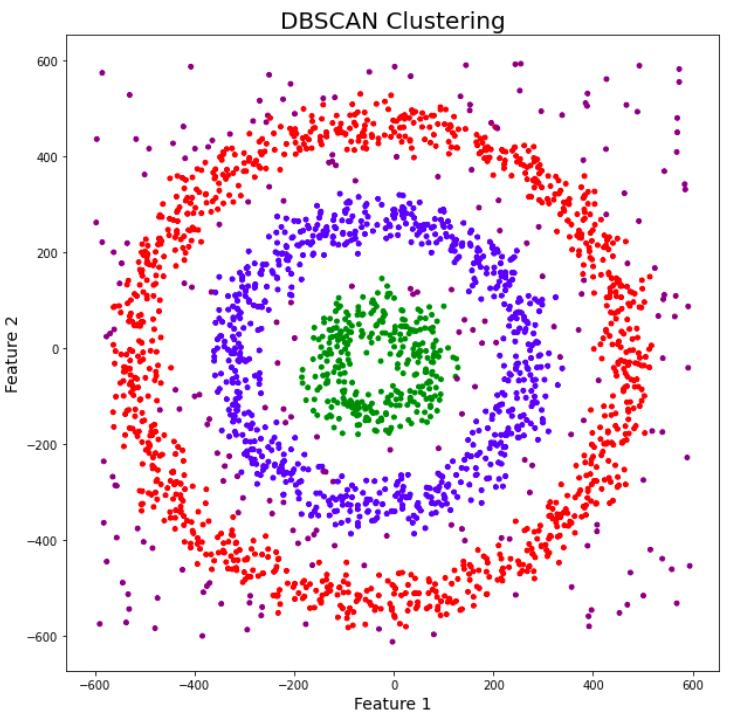
*DBSCAN groups nearby points into clusters while isolated points are classified as noise.*

# Ilustration 2-Type of point

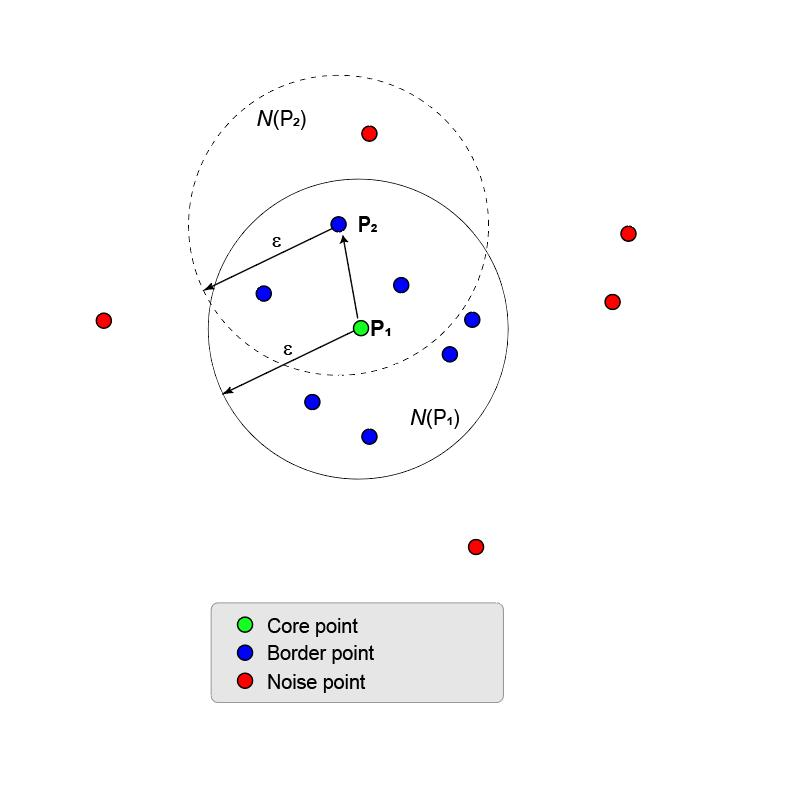

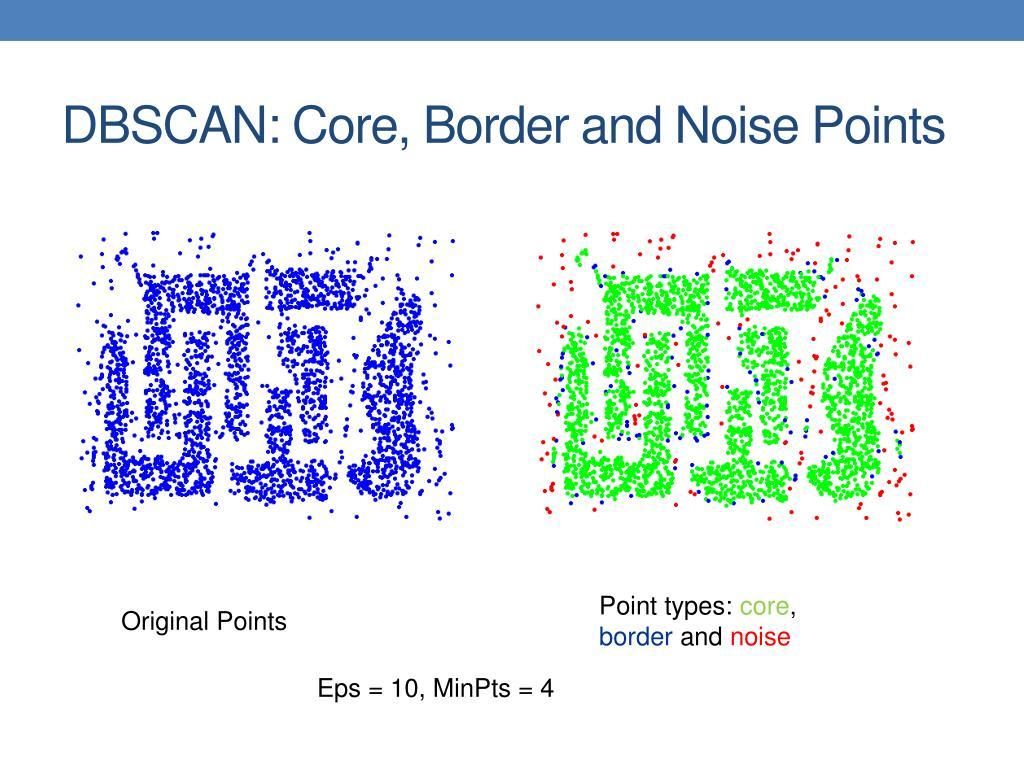

*DBSCAN distinguishes three types of points: Core Points, Border Points, and Noise Points.*

# Illustration 3 — ε-Neighborhood

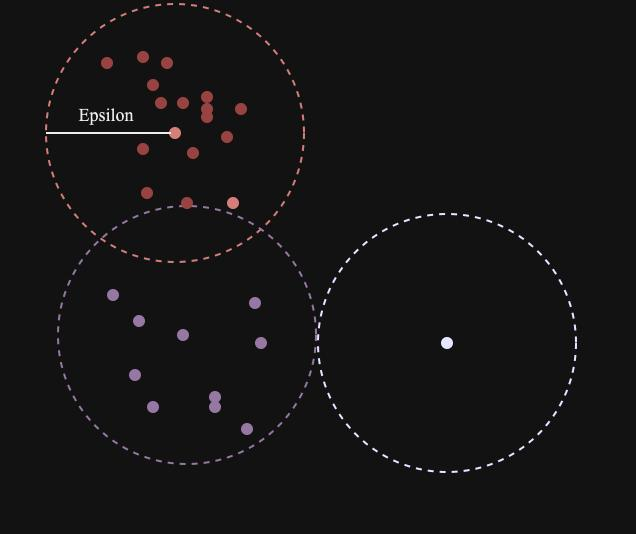

*The ε-neighborhood represents the search radius used to determine neighboring points.*


<h1 style="color: Green; ">#5. Advantages and Limitations of DBSCAN

</h1>



###  Advantages

<span style="color: yellow;">*1. No need to specify the number of clusters:*</span>
Unlike K-Means, DBSCAN automatically discovers the number of clusters present in the data without the user having to define it in advance.

<span style="color: yellow;">*2. Automatic outlier detection*:</span>
DBSCAN naturally identifies noise points (outliers) by labeling them **-1**, which most other algorithms do not do.

<span style="color: yellow;">*3. Clusters of arbitrary shapes*:</span>
DBSCAN can detect clusters of any shape (circular, elongated, spiral, crescent) unlike K-Means which assumes spherical clusters.

<span style="color: yellow;">*4. Robust to noise*:</span>
The algorithm is not sensitive to outliers as it isolates them automatically without disturbing the formation of clusters.

<span style="color: yellow;">*5. No assumption on data distribution*:</span>
DBSCAN assumes no particular distribution of the data, making it very flexible and applicable to many types of data.

---

### Limitations

<span style="color: yellow;">*1. Sensitive to ε and minPts choices:*</span>
If the parameters are poorly chosen, the results can be very poor. A ε too small creates too much noise, a ε too large merges all clusters into one.

<span style="color: yellow;">*2. Difficulty with varying densities:*</span>
DBSCAN uses a single radius ε for the entire dataset. If some clusters are denser than others, the algorithm will struggle to detect them all correctly.

<span style="color: yellow;">*3. Poor performance in high dimensions*:</span>
In high-dimensional spaces, the notion of distance becomes less meaningful, which reduces the effectiveness of DBSCAN.

<span style="color: yellow;">*4. High computational cost*:</span>
The complexity of DBSCAN is O(n²) in the worst case, which can be very slow on very large datasets.

<span style="color: yellow;">*5. Not suitable for very sparse data*:</span>
If the data is very scattered in space, DBSCAN will tend to classify the majority of points as noise.

---

### Summary

| | DBSCAN | K-Means |
|---|---|---|
| Number of clusters | Automatic | Manual |
| Outlier detection | Yes | No |
| Cluster shapes | Any shape | Spherical only |
| Varying densities | Difficult | Correct |
| Speed | O(n²) | Fast |


<h1 style="color: Green ; ">#6-Real-World Applications of DBSCAN
</h1>


### 1. Anomaly Detection in Banking
DBSCAN can detect fraudulent transactions by identifying points that do not belong to any cluster (outliers).

### 2. Urban Zone Analysis
DBSCAN can group geographic zones by density of population, traffic, or incidents to help city planners make better decisions.

### 3. Medical Diagnosis
DBSCAN can identify abnormal groups of cells in medical imaging data, helping doctors detect diseases like cancer.

### 4. Social Network Analysis
DBSCAN can detect communities or suspicious groups in social networks based on interaction patterns.

### 5. Environmental Monitoring
DBSCAN can group sensor data to detect pollution zones or abnormal climate patterns.

<h1 style="color: Green; ">#7-Implementation : Custom Library vs Scikit-learn

</h1> 


### 7.1 Custom DBSCAN Implementation
We will first build our own DBSCAN library from scratch, then compare its results with the Scikit-learn implementation.

In [ ]:
import sys
sys.path.append("C:\Users\HP\Documents\projet mini-ml-ifri\ifri_mini_ml_lib")

In [ ]:
import numpy as np

class CustomDBSCAN:
    """
    Custom implementation of the DBSCAN clustering algorithm.
    
    Parameters
    ----------
    eps : float
        The maximum distance between two points to be considered neighbors.
    min_samples : int
        The minimum number of points required to form a core point.
    """
    
    def __init__(self, eps=0.5, min_samples=5):
        self.eps = eps
        self.min_samples = min_samples
        self.labels_ = None

    def _get_neighbors(self, X, point_idx):
        """Find all neighbors of a point within radius epsilon."""
        neighbors = []
        for i in range(len(X)):
            distance = np.sqrt(np.sum((X[point_idx] - X[i]) ** 2))
            if distance <= self.eps:
                neighbors.append(i)
        return neighbors

    def _expand_cluster(self, X, visited, labels, point_idx, neighbors, cluster_id):
        """Expand the cluster from a core point."""
        labels[point_idx] = cluster_id
        i = 0
        while i < len(neighbors):
            neighbor = neighbors[i]
            if not visited[neighbor]:
                visited[neighbor] = True
                new_neighbors = self._get_neighbors(X, neighbor)
                if len(new_neighbors) >= self.min_samples:
                    neighbors += new_neighbors
            if labels[neighbor] == -1:
                labels[neighbor] = cluster_id
            i += 1

    def fit_predict(self, X):
        """
        Fit the model and return cluster labels.
        
        Parameters
        ----------
        X : array-like of shape (n_samples, n_features)
        
        Returns
        -------
        labels : array of shape (n_samples,)
            -1 for noise points, >= 0 for cluster members.
        """
        visited = [False] * len(X)
        labels = [-1] * len(X)
        cluster_id = 0

        for i in range(len(X)):
            if not visited[i]:
                visited[i] = True
                neighbors = self._get_neighbors(X, i)

                if len(neighbors) >= self.min_samples:
                    self._expand_cluster(X, visited, labels, i, neighbors, cluster_id)
                    cluster_id += 1

        self.labels_ = np.array(labels)
        return self.labels_

<h3 style="color:pink"> Code (Génération des données) :
</h3>

In [ ]:
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt

# Generate dataset
X, _ = make_moons(n_samples=300, noise=0.1, random_state=42)

plt.figure(figsize=(6, 4))
plt.scatter(X[:, 0], X[:, 1], s=30, color='gray')
plt.title("Dataset — make_moons")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

<h3 style="color:pink"> Code (Custom DBSCAN) :

In [ ]:
import time

# Apply Custom DBSCAN
start_custom = time.time()
custom_model = CustomDBSCAN(eps=0.2, min_samples=5)
custom_labels = custom_model.fit_predict(X)
end_custom = time.time()

# Visualization
plt.figure(figsize=(6, 4))
plt.scatter(X[:, 0], X[:, 1], c=custom_labels, cmap='plasma', s=30)
plt.title("Custom DBSCAN Result")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.colorbar(label="Cluster (-1 = Noise)")
plt.show()

print(f"Custom DBSCAN")
print(f"  Clusters found   : {len(set(custom_labels)) - (1 if -1 in custom_labels else 0)}")
print(f"  Noise points     : {list(custom_labels).count(-1)}")
print(f"  Execution time   : {round(end_custom - start_custom, 4)} seconds")

<h3 style="color:pink"> Code (Scikit-learn DBSCAN) :
</h3>

In [ ]:
from sklearn.cluster import DBSCAN

# Apply Scikit-learn DBSCAN
start_sklearn = time.time()
sklearn_model = DBSCAN(eps=0.2, min_samples=5)
sklearn_labels = sklearn_model.fit_predict(X)
end_sklearn = time.time()

# Visualization
plt.figure(figsize=(6, 4))
plt.scatter(X[:, 0], X[:, 1], c=sklearn_labels, cmap='plasma', s=30)
plt.title("Scikit-learn DBSCAN Result")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.colorbar(label="Cluster (-1 = Noise)")
plt.show()

print(f"Scikit-learn DBSCAN")
print(f"  Clusters found   : {len(set(sklearn_labels)) - (1 if -1 in sklearn_labels else 0)}")
print(f"  Noise points     : {list(sklearn_labels).count(-1)}")
print(f"  Execution time   : {round(end_sklearn - start_sklearn, 4)} seconds")

<h3 style="color:pink">  Code (Comparaison côte à côte) :
</h3>

In [ ]:
# Side by side comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Custom DBSCAN
axes[0].scatter(X[:, 0], X[:, 1], c=custom_labels, cmap='plasma', s=30)
axes[0].set_title("Custom DBSCAN")
axes[0].set_xlabel("Feature 1")
axes[0].set_ylabel("Feature 2")

# Scikit-learn DBSCAN
axes[1].scatter(X[:, 0], X[:, 1], c=sklearn_labels, cmap='plasma', s=30)
axes[1].set_title("Scikit-learn DBSCAN")
axes[1].set_xlabel("Feature 1")
axes[1].set_ylabel("Feature 2")

plt.suptitle("Custom DBSCAN vs Scikit-learn DBSCAN", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Comparison Table
print("=" * 45)
print(f"{'Metric':<25} {'Custom':>8} {'Sklearn':>8}")
print("=" * 45)
print(f"{'Clusters found':<25} {len(set(custom_labels)) - (1 if -1 in custom_labels else 0):>8} {len(set(sklearn_labels)) - (1 if -1 in sklearn_labels else 0):>8}")
print(f"{'Noise points':<25} {list(custom_labels).count(-1):>8} {list(sklearn_labels).count(-1):>8}")
print(f"{'Execution time (s)':<25} {round(end_custom - start_custom, 4):>8} {round(end_sklearn - start_sklearn, 4):>8}")
print(f"{'Same results':<25} {'Yes' if list(custom_labels) == list(sklearn_labels) else 'No':>8}")
print("=" * 45)

### 7.2 Comparison Results

The comparison between our **Custom DBSCAN** and **Scikit-learn DBSCAN** shows that :

- Both implementations produce the **same clustering results** when using identical parameters.
- Scikit-learn is significantly **faster** because it uses optimized data structures like **KD-Tree** and **Ball-Tree** internally.
- Our custom implementation is useful for **understanding the algorithm** step by step but is not recommended for large datasets due to its **O(n²) complexity**.